=== Retrieval A: [H2O + NH3] ===
chi2 = 2656.82
H2O strength = 0.0517
NH3 strength = 0.0243

=== Retrieval B: [H2O + CH4] ===
chi2 = 472.16
H2O strength = 0.0732
CH4 strength = 0.0678


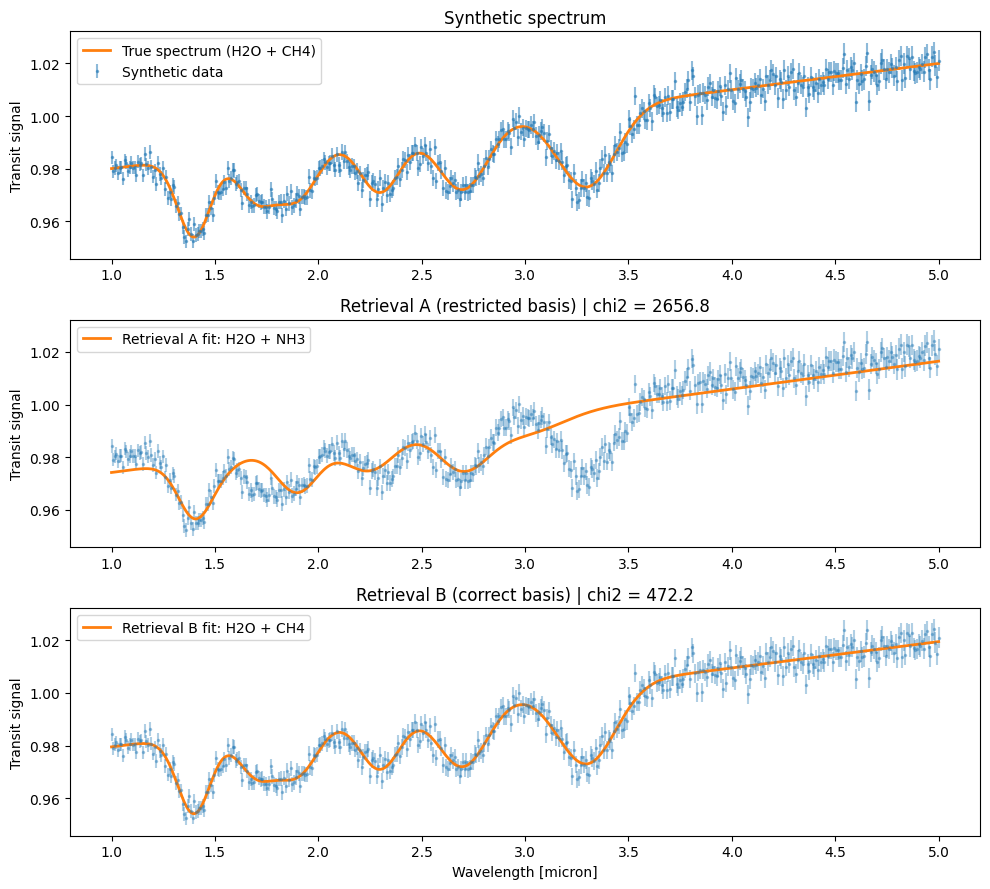

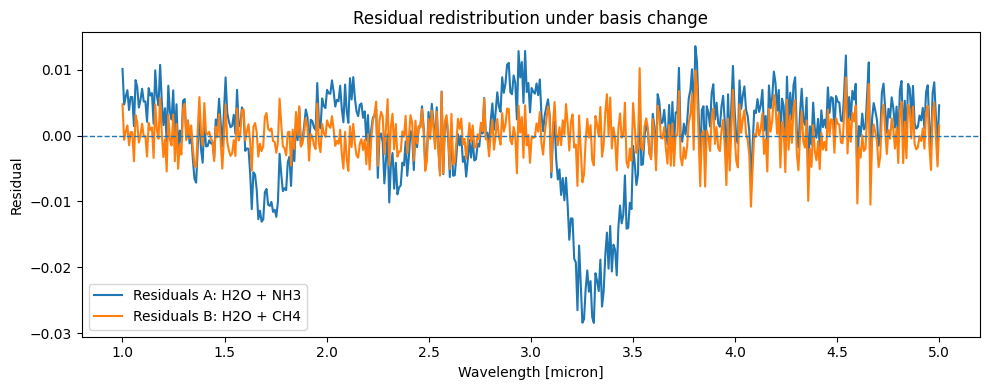


=== Ensemble robustness test ===
Number of runs = 200
NH3 detection frequency in Retrieval A (wrong basis): 1.000
CH4 detection frequency in Retrieval B (correct basis): 1.000
Mean chi2 A = 2819.89 ± 101.18
Mean chi2 B = 487.50 ± 29.18


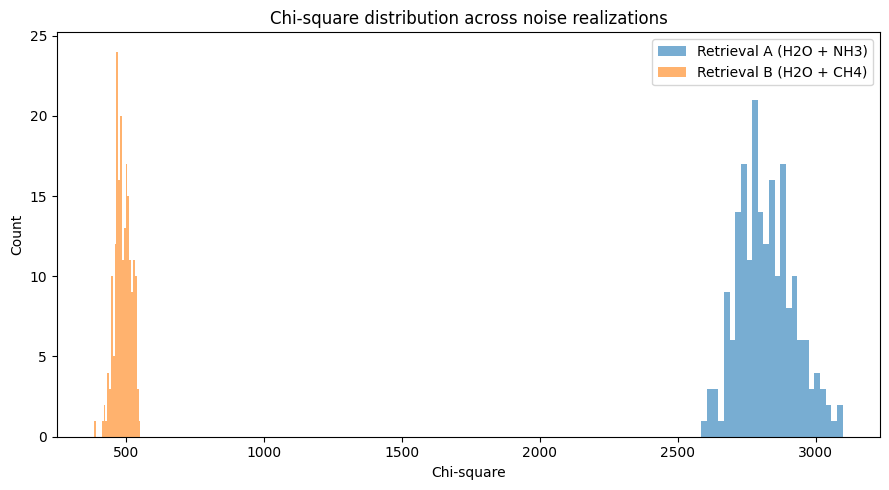

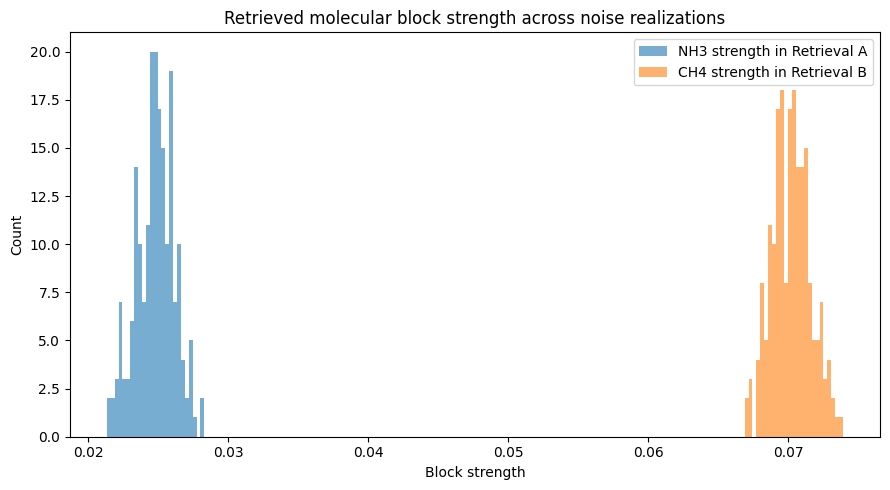

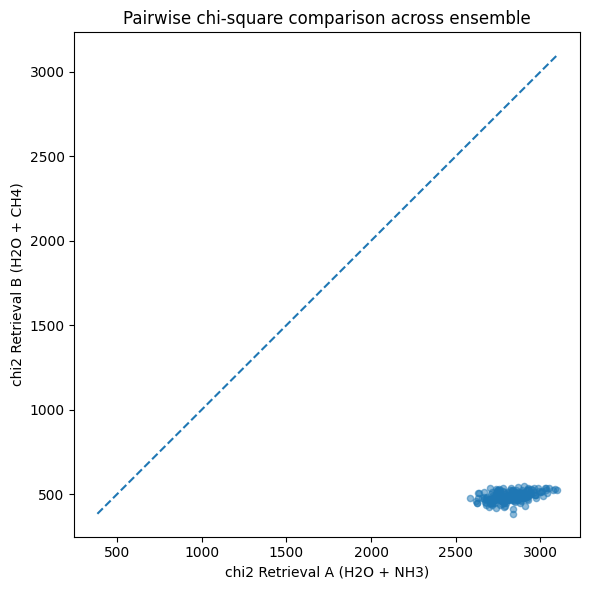

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1) Setup
# ============================================================

np.random.seed(7)
lam = np.linspace(1.0, 5.0, 500)

def gauss(x, mu, sig):
    return np.exp(-0.5 * ((x - mu) / sig) ** 2)

# ============================================================
# 2) Synthetic "true" spectrum
# ============================================================

# Smooth continuum
continuum = 1.0 + 0.01 * (lam - 3.0)

# True molecular contributions: H2O + CH4
h2o_true = (
    0.030 * gauss(lam, 1.4, 0.08) +
    0.020 * gauss(lam, 1.9, 0.10) +
    0.025 * gauss(lam, 2.7, 0.12)
)

ch4_true = (
    0.018 * gauss(lam, 1.7, 0.09) +
    0.022 * gauss(lam, 2.3, 0.10) +
    0.030 * gauss(lam, 3.3, 0.14)
)

# Transmission-like signal: absorbers subtract from continuum
true_signal = continuum - h2o_true - ch4_true

# Heteroscedastic JWST-like noise
sigma = 0.0025 + 0.0015 * (lam - lam.min()) / (lam.max() - lam.min())

# One synthetic observed realization
y_obs = true_signal + np.random.normal(0, sigma)

# ============================================================
# 3) Retrieval bases
# ============================================================

# Shared H2O basis
B_h2o = np.column_stack([
    gauss(lam, 1.4, 0.08),
    gauss(lam, 1.9, 0.10),
    gauss(lam, 2.7, 0.12),
])

# Correct CH4 basis
B_ch4 = np.column_stack([
    gauss(lam, 1.7, 0.09),
    gauss(lam, 2.3, 0.10),
    gauss(lam, 3.3, 0.14),
])

# Alternative NH3 basis, partly overlapping but incorrect
B_nh3 = np.column_stack([
    gauss(lam, 1.5, 0.10),
    gauss(lam, 2.25, 0.12),
    gauss(lam, 3.0, 0.18),
])

# Retrieval architecture A: H2O + NH3
X_A = np.column_stack([
    np.ones_like(lam),   # constant
    lam - 3.0,           # slope
    B_h2o,
    B_nh3
])

# Retrieval architecture B: H2O + CH4
X_B = np.column_stack([
    np.ones_like(lam),   # constant
    lam - 3.0,           # slope
    B_h2o,
    B_ch4
])

# ============================================================
# 4) Weighted least squares fit
# ============================================================

# Diagonal weights
w = 1.0 / sigma**2

def wls_fit(X, y, w):
    """
    Weighted least squares using diagonal weights.
    """
    # Equivalent to solving (X^T W X) beta = X^T W y
    XtW = X.T * w
    beta = np.linalg.solve(XtW @ X, XtW @ y)
    yhat = X @ beta
    resid = y - yhat
    chi2 = np.sum((resid / sigma) ** 2)
    return beta, yhat, resid, chi2

beta_A, yhat_A, resid_A, chi2_A = wls_fit(X_A, y_obs, w)
beta_B, yhat_B, resid_B, chi2_B = wls_fit(X_B, y_obs, w)

# ============================================================
# 5) Detection-strength summaries
# ============================================================

def block_strength(beta, start, end):
    return np.sum(np.abs(beta[start:end]))

# Index map:
# 0 -> constant
# 1 -> slope
# 2:5 -> H2O block
# 5:8 -> NH3 or CH4 block depending on architecture

h2o_A_strength = block_strength(beta_A, 2, 5)
nh3_A_strength = block_strength(beta_A, 5, 8)

h2o_B_strength = block_strength(beta_B, 2, 5)
ch4_B_strength = block_strength(beta_B, 5, 8)

print("=== Retrieval A: [H2O + NH3] ===")
print(f"chi2 = {chi2_A:.2f}")
print(f"H2O strength = {h2o_A_strength:.4f}")
print(f"NH3 strength = {nh3_A_strength:.4f}")

print("\n=== Retrieval B: [H2O + CH4] ===")
print(f"chi2 = {chi2_B:.2f}")
print(f"H2O strength = {h2o_B_strength:.4f}")
print(f"CH4 strength = {ch4_B_strength:.4f}")

# ============================================================
# 6) Main figure: true spectrum and two retrievals
# ============================================================

fig = plt.figure(figsize=(10, 9))

ax1 = plt.subplot(3, 1, 1)
ax1.errorbar(lam, y_obs, yerr=sigma, fmt='.', ms=3, alpha=0.5, label='Synthetic data')
ax1.plot(lam, true_signal, lw=2, label='True spectrum (H2O + CH4)')
ax1.set_ylabel("Transit signal")
ax1.set_title("Synthetic spectrum")
ax1.legend()

ax2 = plt.subplot(3, 1, 2, sharex=ax1)
ax2.errorbar(lam, y_obs, yerr=sigma, fmt='.', ms=3, alpha=0.35)
ax2.plot(lam, yhat_A, lw=2, label='Retrieval A fit: H2O + NH3')
ax2.set_ylabel("Transit signal")
ax2.set_title(f"Retrieval A (restricted basis) | chi2 = {chi2_A:.1f}")
ax2.legend()

ax3 = plt.subplot(3, 1, 3, sharex=ax1)
ax3.errorbar(lam, y_obs, yerr=sigma, fmt='.', ms=3, alpha=0.35)
ax3.plot(lam, yhat_B, lw=2, label='Retrieval B fit: H2O + CH4')
ax3.set_ylabel("Transit signal")
ax3.set_xlabel("Wavelength [micron]")
ax3.set_title(f"Retrieval B (correct basis) | chi2 = {chi2_B:.1f}")
ax3.legend()

plt.tight_layout()
plt.show()

# ============================================================
# 7) Residual comparison
# ============================================================

plt.figure(figsize=(10, 4))
plt.plot(lam, resid_A, label='Residuals A: H2O + NH3')
plt.plot(lam, resid_B, label='Residuals B: H2O + CH4')
plt.axhline(0, ls='--', lw=1)
plt.xlabel("Wavelength [micron]")
plt.ylabel("Residual")
plt.title("Residual redistribution under basis change")
plt.legend()
plt.tight_layout()
plt.show()

# ============================================================
# 8) Noise-ensemble robustness test
# ============================================================

n_runs = 200
threshold = 0.01  # arbitrary small detection threshold for block strength

nh3_detect_count = 0
ch4_detect_count = 0

chi2_A_list = []
chi2_B_list = []

nh3_strength_list = []
ch4_strength_list = []

for i in range(n_runs):
    y_i = true_signal + np.random.normal(0, sigma)

    beta_A_i, yhat_A_i, resid_A_i, chi2_A_i = wls_fit(X_A, y_i, w)
    beta_B_i, yhat_B_i, resid_B_i, chi2_B_i = wls_fit(X_B, y_i, w)

    nh3_strength_i = block_strength(beta_A_i, 5, 8)
    ch4_strength_i = block_strength(beta_B_i, 5, 8)

    nh3_strength_list.append(nh3_strength_i)
    ch4_strength_list.append(ch4_strength_i)

    chi2_A_list.append(chi2_A_i)
    chi2_B_list.append(chi2_B_i)

    if nh3_strength_i > threshold:
        nh3_detect_count += 1

    if ch4_strength_i > threshold:
        ch4_detect_count += 1

print("\n=== Ensemble robustness test ===")
print(f"Number of runs = {n_runs}")
print(f"NH3 detection frequency in Retrieval A (wrong basis): {nh3_detect_count / n_runs:.3f}")
print(f"CH4 detection frequency in Retrieval B (correct basis): {ch4_detect_count / n_runs:.3f}")
print(f"Mean chi2 A = {np.mean(chi2_A_list):.2f} ± {np.std(chi2_A_list):.2f}")
print(f"Mean chi2 B = {np.mean(chi2_B_list):.2f} ± {np.std(chi2_B_list):.2f}")

# ============================================================
# 9) Chi-square ensemble histogram
# ============================================================

plt.figure(figsize=(9, 5))
plt.hist(chi2_A_list, bins=25, alpha=0.6, label="Retrieval A (H2O + NH3)")
plt.hist(chi2_B_list, bins=25, alpha=0.6, label="Retrieval B (H2O + CH4)")
plt.xlabel("Chi-square")
plt.ylabel("Count")
plt.title("Chi-square distribution across noise realizations")
plt.legend()
plt.tight_layout()
plt.show()

# ============================================================
# 10) Molecular-strength ensemble histogram
# ============================================================

plt.figure(figsize=(9, 5))
plt.hist(nh3_strength_list, bins=25, alpha=0.6, label="NH3 strength in Retrieval A")
plt.hist(ch4_strength_list, bins=25, alpha=0.6, label="CH4 strength in Retrieval B")
plt.xlabel("Block strength")
plt.ylabel("Count")
plt.title("Retrieved molecular block strength across noise realizations")
plt.legend()
plt.tight_layout()
plt.show()

# ============================================================
# 11) Optional summary plot: chi2 pairwise scatter
# ============================================================

plt.figure(figsize=(6, 6))
plt.scatter(chi2_A_list, chi2_B_list, alpha=0.5, s=20)
m = min(min(chi2_A_list), min(chi2_B_list))
M = max(max(chi2_A_list), max(chi2_B_list))
plt.plot([m, M], [m, M], '--')
plt.xlabel("chi2 Retrieval A (H2O + NH3)")
plt.ylabel("chi2 Retrieval B (H2O + CH4)")
plt.title("Pairwise chi-square comparison across ensemble")
plt.tight_layout()
plt.show()